# T6 — Behavioural Response Analysis

Classifies each participant's gait response to the tempo manipulation and analyses left/right pressure asymmetry across participants.

**Depends on** `01_pressure_analysis.ipynb` — run that first.

## Contents
- **Feature extraction** — compliance score, consistency score, drift score per participant
- **Profile classification** — assigns each participant to a response category (*Consistent influence*, *Subconscious correction*, *Drift*, *No clear effect*)
- **Visualisation** — 2D characterisation scatter, trajectory viewer, profile grid
- **Figure 5** — influence ranking and summary table
- **Permutation test** — validates that the categorisation detects real manipulation effects
- **Exports** — profile assignments and influence scores to `exports/figure5/`

In [351]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display
from scipy.signal import find_peaks, savgol_filter
from scipy.ndimage import gaussian_filter1d
from scipy import stats

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 14})

DATA_DIR = Path(".")

PROFILE_COLORS = {
    # ── Clear profiles ──────────────────────────────────────────────────────
    "Compliant":              "#27ae60",   # tracked target throughout
    "Follow-then-correct":    "#e74c3c",   # tracked then consciously corrected back
    "Drift-in sensitive":     "#8e44ad",   # responded to ramp-in, dropped in plateau
    "Drift-sensitive":        "#6c3483",   # responded to BOTH ramp-in and ramp-out changes
    "Fade-out sensitive":     "#e67e22",   # unaffected during plateau, responds to return
    "Comply + overcorrect":   "#c0392b",   # tracked target, overshot opposite on return
    "Resistant":              "#7f8c8d",   # no detectable effect throughout
    # ── Descriptive partial profiles (replace "Mixed") ──────────────────────
    "Partial: drift-in":      "#a569bd",   # weak ramp-in response, drops in plateau
    "Partial: compliance":    "#52be80",   # moves in right direction overall, too weak
    "Partial: fade-out":      "#f0b27a",   # weak opposite movement in ramp-out only
    "No clear pattern":       "#aab7b8",   # genuinely flat / noisy
}

# ── Canonical colour palette (shared across all notebooks) ───────────────────
# CATEGORY_COLORS = {
#     "No clear effect":               "#7f8c8d",   # grey
#     "Impact only from drift phases":  "#e67e22",   # orange
#     "Subconscious correction":        "#3498db",   # blue
#     "Consistent influence":           "#27ae60",   # green
# }
# FOOT_COLORS = {"L": "#1f77b4", "R": "#d62728"}    # blue = left, red = right
# DIRECTION_COLORS = {"increasing": "#2980b9", "decreasing": "#c0392b",
#                     "speeding up": "#2980b9", "slowing down": "#c0392b"}
# ─────────────────────────────────────────────────────────────────────────────



def _trapezoid_target(t_norm, target_sign, fade_frac=0.20):
    """Trapezoid: smoothstep ramp 0→±8%, flat plateau, smoothstep ramp back."""
    def ss(x):
        x = np.clip(x, 0.0, 1.0)
        return 3.0 * x**2 - 2.0 * x**3
    pct = np.where(
        t_norm <= fade_frac,
        ss(t_norm / fade_frac),
        np.where(t_norm >= 1.0 - fade_frac,
                 ss((1.0 - t_norm) / fade_frac), 1.0)
    )
    return target_sign * 8.0 * pct


def _trapezoid_accel(t_norm, target_sign, fade_frac=0.20):
    """Analytical second derivative — no boundary artefacts."""
    accel = np.zeros_like(t_norm, dtype=float)
    k = target_sign * 8.0 / fade_frac**2
    e = t_norm <= fade_frac
    accel[e] = k * (6.0 - 12.0 * (t_norm[e] / fade_frac))
    l = t_norm >= 1.0 - fade_frac
    accel[l] = k * (6.0 - 12.0 * ((1.0 - t_norm[l]) / fade_frac))
    return accel


def _smooth_accel(signal, frac=0.20, polyorder=3):
    """SG smooth 2nd derivative, mode='nearest'. For cadence only."""
    n   = len(signal)
    win = max(9, int(n * frac))
    if win % 2 == 0:
        win += 1
    win = min(win, n if n % 2 == 1 else n - 1)
    return savgol_filter(signal, window_length=win, polyorder=polyorder,
                         deriv=2, mode='nearest')


def _display_accel(arr, sigma=6):
    """Gaussian-smooth then normalise to ±1 for display."""
    s = gaussian_filter1d(arr.astype(float), sigma=sigma)
    m = np.abs(s).max()
    return s / m if m > 1e-9 else s


print("Setup complete.")

Setup complete.


In [352]:
# ── Core utilities (mirrored from main notebook) ────────────────────────────

def parse_pressure_file(path):
    path = Path(path)
    if not path.exists(): return pd.DataFrame()
    raw  = path.read_bytes()
    data = raw.replace(b"\r\n", b"\n").replace(b"\r", b"\n").decode("utf-8", errors="replace")
    rows = []
    for rec in [r.strip() for r in data.split(";") if r.strip()]:
        rec  = re.sub(r"^\d+,\s*", "", rec)
        nums = re.findall(r"[\d]+\.?[\d]*", rec)
        if len(nums) < 5: continue
        try:
            ts = float(nums[0])
            s  = [float(n) for n in nums[1:] if float(n) <= 1023]
            if len(s) >= 4:
                rows.append({"ts_ms": ts, "L_heel": s[1], "R_heel": s[3]})
        except ValueError: pass
    if not rows: return pd.DataFrame()
    df = pd.DataFrame(rows)
    df["time_s"] = (df["ts_ms"] - df["ts_ms"].iloc[0]) / 1000.0
    return df


def _rolling_cadence(df, window_s=15):
    if df is None or df.empty: return np.array([]), np.array([])
    t_arr = df["time_s"].to_numpy()
    if len(t_arr) < 2: return np.array([]), np.array([])
    dt_ms    = float(np.median(np.diff(t_arr)) * 1000)
    min_dist = max(1, int(round(400 / dt_ms)))
    peak_times = []
    for col in ("L_heel", "R_heel"):
        if col not in df.columns: continue
        idx = find_peaks(df[col].to_numpy().astype(float), prominence=50, distance=min_dist)[0]
        peak_times.extend(t_arr[idx].tolist())
    if not peak_times: return np.array([]), np.array([])
    peak_times = np.sort(peak_times)
    t_max = float(t_arr[-1]); half = window_s / 2.0
    grid  = np.arange(0, t_max, 1.0)
    cad   = np.array([
        (np.searchsorted(peak_times, min(t_max, t+half)) -
         np.searchsorted(peak_times, max(0.0, t-half))) /
        max(min(t_max, t+half) - max(0.0, t-half), 0.001) * 60.0
        for t in grid], dtype=float)
    return grid, cad


_summary = pd.read_excel(DATA_DIR / "Test 6_summary.xlsx", header=2)
_summary["ID"] = _summary["ID"].astype(str).str.zfill(2)
_summary = _summary.set_index("ID")

def get_participant_meta(pid):
    if pid not in _summary.index: return "", ""
    row = _summary.loc[pid]
    order     = "tempo first" if str(row["condition order"]).strip().lower() == "a-first" else "weight first"
    direction = str(row["tempo direction"]).strip().replace("_", " ")
    return order, direction


_BASELINE_WIN_S    = 30
_BASELINE_AGREE_PCT = 8.0

def compute_smart_baseline(pid):
    order, _ = get_participant_meta(pid)
    weight_first = order.startswith("weight")
    paths = {ph: DATA_DIR / pid / f"{pid}_pressure_{ph}.csv"
             for ph in ("pondering", "weight", "tempo")}
    specs = ({1: [("pondering","last"),("weight","first")],
              2: [("weight","last"),("tempo","first")]} if weight_first else
             {1: [("pondering","last"),("tempo","first")],
              2: [("tempo","last"),("weight","first")]})
    _dfs = {}
    def _df(ph):
        if ph not in _dfs: _dfs[ph] = parse_pressure_file(paths[ph])
        return _dfs[ph]
    def _win(ph, pos):
        df = _df(ph)
        if df.empty: return None, None, None
        g, c = _rolling_cadence(df, 15)
        if not len(g): return None, None, None
        t_max = float(g[-1])
        t0 = 0.0 if pos=="first" else max(0.0, t_max-_BASELINE_WIN_S)
        t1 = min(_BASELINE_WIN_S, t_max) if pos=="first" else t_max
        m  = (g>=t0)&(g<=t1)
        return (t0, t1, float(c[m].mean())) if m.sum()>=5 else (None,None,None)
    baselines = {}
    for grp, sp_list in specs.items():
        corr_spec, anch_spec = sp_list[0], sp_list[1]
        _, _, a_mean = _win(*anch_spec)
        if a_mean is None: baselines[grp]=None; continue
        a0,a1,_ = _win(*anch_spec)
        c0,c1,c_mean = _win(*corr_spec)
        agree = (c_mean is not None and
                 abs(c_mean - a_mean) / a_mean * 100 <= _BASELINE_AGREE_PCT)
        if agree:
            da, dc = a1-a0, c1-c0
            baselines[grp] = (a_mean*da + c_mean*dc) / (da+dc)
        else:
            baselines[grp] = a_mean
    return baselines.get(2 if weight_first else 1)


EXCLUDED = {"excluded data"}
participants = sorted([
    d.name for d in DATA_DIR.iterdir()
    if d.is_dir() and d.name not in EXCLUDED and any(d.glob("*pressure*"))
])
print(f"Found {len(participants)} participant folders.")

Found 24 participant folders.


In [353]:
# ── Feature extraction ──────────────────────────────────────────────────────

FADE_FRAC = 0.20


def get_weight_cadence_sd(pid, window_s=30):
    df = parse_pressure_file(DATA_DIR / pid / f"{pid}_pressure_weight.csv")
    if df.empty: return 1.0
    _, cad = _rolling_cadence(df, window_s=window_s)
    sd = float(cad.std()) if len(cad) > 1 else 1.0
    return sd if sd > 0.1 else 1.0


def extract_behavioral_features(pid, window_s=15, phase_window_s=30,
                                 phase="tempo", baseline_override=None):
    order, direction = get_participant_meta(pid)
    if not direction: return None
    baseline = baseline_override or compute_smart_baseline(pid)
    if baseline is None: return None
    path = DATA_DIR / pid / f"{pid}_pressure_{phase}.csv"
    df   = parse_pressure_file(path)
    if df.empty: return None

    grid_f, cad_f = _rolling_cadence(df, window_s=phase_window_s)
    grid_d, cad_d = _rolling_cadence(df, window_s=window_s)
    if len(grid_f) == 0: return None

    baseline_sd = get_weight_cadence_sd(pid, window_s=phase_window_s)
    t_norm_f = grid_f / grid_f[-1]
    t_norm_d = grid_d / grid_d[-1] if len(grid_d) > 0 else t_norm_f

    speeding_up = direction != "slowing down"
    target_sign = 1.0 if speeding_up else -1.0

    target_pct_f = (_trapezoid_target(t_norm_f, target_sign) if phase=="tempo" else np.zeros_like(t_norm_f))
    target_pct_d = (_trapezoid_target(t_norm_d, target_sign) if phase=="tempo" else np.zeros_like(t_norm_d))
    target_abs_f = baseline * (1 + target_pct_f / 100.0)
    target_abs_d = baseline * (1 + target_pct_d / 100.0)

    d_target_f   = cad_f - target_abs_f
    d_baseline_f = cad_f - baseline
    d_target_d   = cad_d - target_abs_d

    e_mask = t_norm_f <= FADE_FRAC
    m_mask = (t_norm_f > FADE_FRAC) & (t_norm_f <= 1.0 - FADE_FRAC)
    l_mask = t_norm_f > 1.0 - FADE_FRAC

    def _pm(arr, mask): return float(arr[mask].mean()) if mask.sum() > 0 else 0.0

    early_dev  = _pm(d_target_f,   e_mask)
    mid_dev    = _pm(d_target_f,   m_mask)
    late_dev   = _pm(d_target_f,   l_mask)
    early_base = _pm(d_baseline_f, e_mask)
    mid_base   = _pm(d_baseline_f, m_mask)
    late_base  = _pm(d_baseline_f, l_mask)

    correct_early = float(target_sign * early_base)
    correct_mid   = float(target_sign * mid_base)
    opposite_late = float(-target_sign * late_base)

    def _z(x): return x / baseline_sd

    correct_early_z  = _z(correct_early)
    correct_mid_z    = _z(correct_mid)
    opposite_late_z  = _z(opposite_late)
    early_dev_z      = _z(early_dev)
    mid_dev_z        = _z(mid_dev)
    late_dev_z       = _z(late_dev)
    plateau_drop_z   = correct_early_z - correct_mid_z

    def safe_corr(a, b):
        if a.std() < 1e-6 or b.std() < 1e-6: return 0.0
        return float(np.corrcoef(a, b)[0, 1])

    r_level = safe_corr(cad_f, target_pct_f)
    r_deriv = safe_corr(cad_f, np.gradient(target_pct_f, t_norm_f))

    target_accel_f = (_trapezoid_accel(t_norm_f, target_sign) if phase=="tempo" else np.zeros_like(t_norm_f))
    cad_accel_f    = _smooth_accel(cad_f, frac=0.20)
    r_cad_accel    = safe_corr(cad_accel_f, target_accel_f)

    slope_d       = float(np.polyfit(t_norm_f, d_target_f, 1)[0])
    n_crossings   = int(np.sum(np.diff(np.sign(d_target_f)) != 0))
    peak_dev_time = float(t_norm_f[np.argmax(np.abs(d_target_f))])

    target_amplitude   = baseline * 0.08 + 1e-6
    compliance_score   = float(np.clip(1.0 - np.abs(d_target_f).mean() / target_amplitude, 0, 1))
    correction_index   = float(late_dev - early_dev)
    correction_index_z = _z(correction_index)
    mid_excess         = float(mid_dev - (early_dev + late_dev) / 2.0)
    mid_excess_z       = _z(mid_excess)
    drift_sensitivity  = float(r_deriv - r_level)

    return {
        "pid": pid, "phase": phase, "direction": direction, "order": order,
        "baseline": baseline, "baseline_sd": baseline_sd,
        "early_dev": early_dev, "mid_dev": mid_dev, "late_dev": late_dev,
        "early_base": early_base, "mid_base": mid_base, "late_base": late_base,
        "correct_early": correct_early, "correct_mid": correct_mid,
        "opposite_late": opposite_late,
        "correct_early_z": correct_early_z, "correct_mid_z": correct_mid_z,
        "opposite_late_z": opposite_late_z,
        "early_dev_z": early_dev_z, "mid_dev_z": mid_dev_z, "late_dev_z": late_dev_z,
        "correction_index_z": correction_index_z, "mid_excess_z": mid_excess_z,
        "plateau_drop_z": plateau_drop_z,
        "r_cad_accel": r_cad_accel,
        "r_level": r_level, "r_deriv": r_deriv,
        "slope_d": slope_d, "n_crossings": n_crossings, "peak_dev_time": peak_dev_time,
        "compliance_score": compliance_score,
        "correction_index": correction_index,
        "mid_excess": mid_excess,
        "drift_sensitivity": drift_sensitivity,
        "_t_norm": t_norm_d, "_cadence": cad_d,
        "_target_abs": target_abs_d, "_deviation": d_target_d,
        "_d_baseline": cad_d - baseline,
        "_cad_accel":    np.interp(t_norm_d, t_norm_f, cad_accel_f),
        "_target_accel": np.interp(t_norm_d, t_norm_f, target_accel_f),
    }


def classify_profile(feat):
    """
    Classification into 11 profiles — no more catch-all "Mixed".

    Unambiguous profiles (high-confidence):
      Fade-out sensitive    – unaffected during plateau, went OPPOSITE in ramp-out
      Comply + overcorrect  – tracked target, then overshot opposite on return
      Compliant             – tracked throughout
      Drift-sensitive       – responded to BOTH ramp-in AND ramp-out changes
      Drift-in sensitive    – responded to ramp-in, dropped back in plateau
      Follow-then-correct   – tracked early, consciously corrected back later
      Resistant             – flat throughout

    Descriptive partials (below threshold but not random):
      Partial: drift-in     – weak ramp-in response with plateau drop
      Partial: compliance   – partial sustained movement in target direction
      Partial: fade-out     – weak opposite movement in ramp-out
      No clear pattern      – genuinely noisy, no dominant tendency
    """
    if feat is None: return "Unknown"

    cs   = feat["compliance_score"]
    nc   = feat["n_crossings"]

    ol_z = feat["opposite_late_z"]    # + = went opposite in ramp-out
    ce_z = feat["correct_early_z"]    # + = tracked in ramp-in
    cm_z = feat["correct_mid_z"]      # + = tracked in plateau
    ci_z = feat["correction_index_z"] # + = drifted away late
    ed_z = feat["early_dev_z"]
    pd_z = feat["plateau_drop_z"]     # + = dropped in plateau vs ramp-in

    # ── Minimum effect-size gate ─────────────────────────────────────────────
    # If no feature shows meaningful signal, skip all rules immediately.
    # Prevents natural within-session cadence drift from triggering profiles.
    if (abs(ce_z) < 0.2 and abs(cm_z) < 0.2 and
            abs(ol_z) < 0.2 and cs < 0.25):
        return "No clear pattern"

    # ── Unambiguous: fade-out effects (check before drift-in to avoid overlap) ──
    if ol_z > 0.5 and abs(cm_z) < 0.4 and ce_z < 0.4:
        return "Fade-out sensitive"

    if ol_z > 0.5 and (ce_z > 0.4 or cm_z > 0.4):
        return "Comply + overcorrect"

    # ── Unambiguous: compliance ──
    if cs > 0.55:
        return "Compliant"

    # ── Unambiguous: drift-sensitive (responded to BOTH ramp-in AND ramp-out) ──
    # Ramp-in tracking + plateau drop + also went opposite in ramp-out
    if ce_z > 0.3 and pd_z > 0.4 and cm_z < ce_z - 0.3 and ol_z > 0.3:
        return "Drift-sensitive"

    # ── Unambiguous: drift-in sensitive (ramp-in tracking + plateau drop, no strong ramp-out) ──
    # cm_z < 0.0 required: plateau must be BELOW baseline, not just below ramp-in.
    # This prevents natural warm-up drift (both phases above baseline) from triggering.
    if ce_z > 0.40 and pd_z > 0.45 and cm_z < 0.0:
        return "Drift-in sensitive"

    # ── Unambiguous: follow-then-correct ──
    if ci_z > 0.5 and abs(ed_z) < 0.5 and nc >= 1:
        return "Follow-then-correct"

    # ── Unambiguous: resistant (nothing detectable) ──
    if cs < 0.20 and abs(ol_z) < 0.25 and abs(ce_z) < 0.2 and abs(cm_z) < 0.2:
        return "Resistant"

    # ── Descriptive partials — replace catch-all "Mixed" ────────────────────
    # Find the dominant tendency and label it, even if below the clear threshold.

    # Weak ramp-in response with plateau below baseline
    if ce_z > 0.25 and pd_z > 0.25 and cm_z < 0.0:
        return "Partial: drift-in"

    # Partial sustained movement in the right direction
    if cm_z > 0.15 or (cs > 0.30 and ce_z > 0.0):
        return "Partial: compliance"

    # Weak opposite movement in ramp-out only
    if ol_z > 0.35:
        return "Partial: fade-out"

    # Genuinely no detectable pattern
    return "No clear pattern"


print("Feature extraction functions defined.")

Feature extraction functions defined.


In [354]:
# ── Build DataFrames for all participants ───────────────────────────────────
# Takes ~90s: calls compute_smart_baseline + get_weight_cadence_sd for each participant.

WINDOW_S       = 15   # display / trajectory smoothing window
PHASE_WINDOW_S = 30   # wider window used only for phase deviation features

tempo_rows, weight_rows = [], []

for pid in participants:
    order, direction = get_participant_meta(pid)
    if not direction:
        continue

    baseline = compute_smart_baseline(pid)
    if baseline is None:
        continue

    f = extract_behavioral_features(pid, WINDOW_S, PHASE_WINDOW_S, "tempo", baseline)
    if f:
        f["profile"] = classify_profile(f)
        tempo_rows.append(f)

    f_w = extract_behavioral_features(pid, WINDOW_S, PHASE_WINDOW_S, "weight", baseline)
    if f_w:
        f_w["profile"] = classify_profile(f_w)
        weight_rows.append(f_w)

SCORE_COLS = ["compliance_score", "correction_index_z", "opposite_late_z",
              "correct_early_z", "correct_mid_z", "mid_excess_z",
              "drift_sensitivity", "r_level", "r_deriv", "n_crossings", "baseline_sd"]

df_tempo  = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")}
                           for r in tempo_rows])
df_weight = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")}
                           for r in weight_rows])
_tempo_feat  = {r["pid"]: r for r in tempo_rows}
_weight_feat = {r["pid"]: r for r in weight_rows}

print(f"Tempo sessions:  {len(df_tempo)} participants")
print(f"Weight sessions: {len(df_weight)} participants")
print(f"\nPhase boundaries: ramp-in 0–{FADE_FRAC*100:.0f}%,"
      f" plateau {FADE_FRAC*100:.0f}–{(1-FADE_FRAC)*100:.0f}%,"
      f" ramp-out {(1-FADE_FRAC)*100:.0f}–100%")
print(f"Features computed at {PHASE_WINDOW_S}s window, trajectories displayed at {WINDOW_S}s window")

print("\nProfile distribution (tempo):")
print(df_tempo["profile"].value_counts().to_string())
print("\nProfile distribution (weight — false positives):")
print(df_weight["profile"].value_counts().to_string())

fp_rate = (df_weight["profile"] != "Resistant").mean() * 100
print(f"\nWeight false-positive rate (non-Resistant): {fp_rate:.0f}%")

if len(df_tempo) > 0:
    print(f"\nMedian natural cadence SD (weight session): "
          f"{df_tempo['baseline_sd'].median():.1f} SPM  "
          f"(range {df_tempo['baseline_sd'].min():.1f}–{df_tempo['baseline_sd'].max():.1f})")

Tempo sessions:  23 participants
Weight sessions: 22 participants

Phase boundaries: ramp-in 0–20%, plateau 20–80%, ramp-out 80–100%
Features computed at 30s window, trajectories displayed at 15s window

Profile distribution (tempo):
profile
No clear pattern        7
Partial: compliance     5
Partial: fade-out       5
Comply + overcorrect    2
Fade-out sensitive      1
Follow-then-correct     1
Partial: drift-in       1
Compliant               1

Profile distribution (weight — false positives):
profile
Partial: compliance    9
No clear pattern       6
Compliant              3
Partial: fade-out      3
Fade-out sensitive     1

Weight false-positive rate (non-Resistant): 100%

Median natural cadence SD (weight session): 5.7 SPM  (range 1.0–14.9)


## Figure 1 — 2D characterisation scatter

Each participant plotted by `compliance_score` (x) vs `correction_index` (y), coloured by profile. Filter by tempo direction.

In [355]:
filter_sel = widgets.Dropdown(
    options=["All", "Speeding up", "Slowing down"],
    description="Direction:", style={"description_width": "80px"},
    layout=widgets.Layout(width="220px")
)
show_weight_chk = widgets.Checkbox(value=True, description="Overlay weight data (grey)",
                                    layout=widgets.Layout(width="220px"))
out_fig1 = widgets.Output()

def _draw_fig1(_=None):
    out_fig1.clear_output(wait=True)
    with out_fig1:
        filt = filter_sel.value
        df   = df_tempo.copy()
        if filt == "Speeding up":   df = df[df["direction"] == "speeding up"]
        elif filt == "Slowing down": df = df[df["direction"] == "slowing down"]

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        for ax, (xcol, ycol, xlabel, ylabel) in zip(axes, [
            # Left: z-score space (main classification view)
            ("compliance_score", "opposite_late_z",
             "Compliance score\n(0=unaffected, 1=on target)",
             "Opposite-late z-score\n(+ = went wrong way in fade-out, × natural SD)"),
            # Right: early vs late z-scores (timing view)
            ("correct_early_z", "correct_mid_z",
             "Correct-early z-score\n(+ = followed target in ramp-in)",
             "Correct-mid z-score\n(+ = followed target in plateau)"),
        ]):
            if show_weight_chk.value and xcol in df_weight.columns:
                ax.scatter(df_weight[xcol], df_weight[ycol],
                           c="#bdc3c7", s=50, alpha=0.5, zorder=2, label="Weight (null)")
                for _, r in df_weight.iterrows():
                    ax.annotate(r["pid"], (r[xcol], r[ycol]),
                                fontsize=11, color="#95a5a6", ha="center", va="bottom")

            for profile, color in PROFILE_COLORS.items():
                sub = df[df["profile"] == profile]
                if sub.empty: continue
                ax.scatter(sub[xcol], sub[ycol],
                           c=color, s=100, zorder=4, label=profile,
                           edgecolors="white", linewidths=0.5)
                for _, r in sub.iterrows():
                    ax.annotate(r["pid"], (r[xcol], r[ycol]),
                                fontsize=13, fontweight="bold", color=color,
                                ha="center", va="bottom",
                                xytext=(0, 5), textcoords="offset points")

            ax.axhline(0, color="#bdc3c7", lw=0.8, linestyle="--")
            ax.axvline(0.5 if xcol == "compliance_score" else 0,
                       color="#bdc3c7", lw=0.8, linestyle="--")
            ax.set_xlabel(xlabel, fontsize=14)
            ax.set_ylabel(ylabel, fontsize=14)
            ax.legend(fontsize=11, loc="upper left")
            ax.grid(linestyle="--", alpha=0.3)

        fig.suptitle(f"Behavioural characterisation — {filt}\n"
                     f"(features normalised by each participant's natural cadence SD)",
                     fontsize=18)
        plt.tight_layout()
        plt.show()

filter_sel.observe(_draw_fig1, names="value")
show_weight_chk.observe(_draw_fig1, names="value")
display(widgets.HBox([filter_sel, show_weight_chk]), out_fig1)
_draw_fig1()

Output()

## Figure 2 — Feature distributions + benchmark

Each score shown as overlaid box plots: **tempo** (coloured, real manipulation) vs **weight** (grey, null/false-positive check). The overlap tells you how separable the signal is from noise.

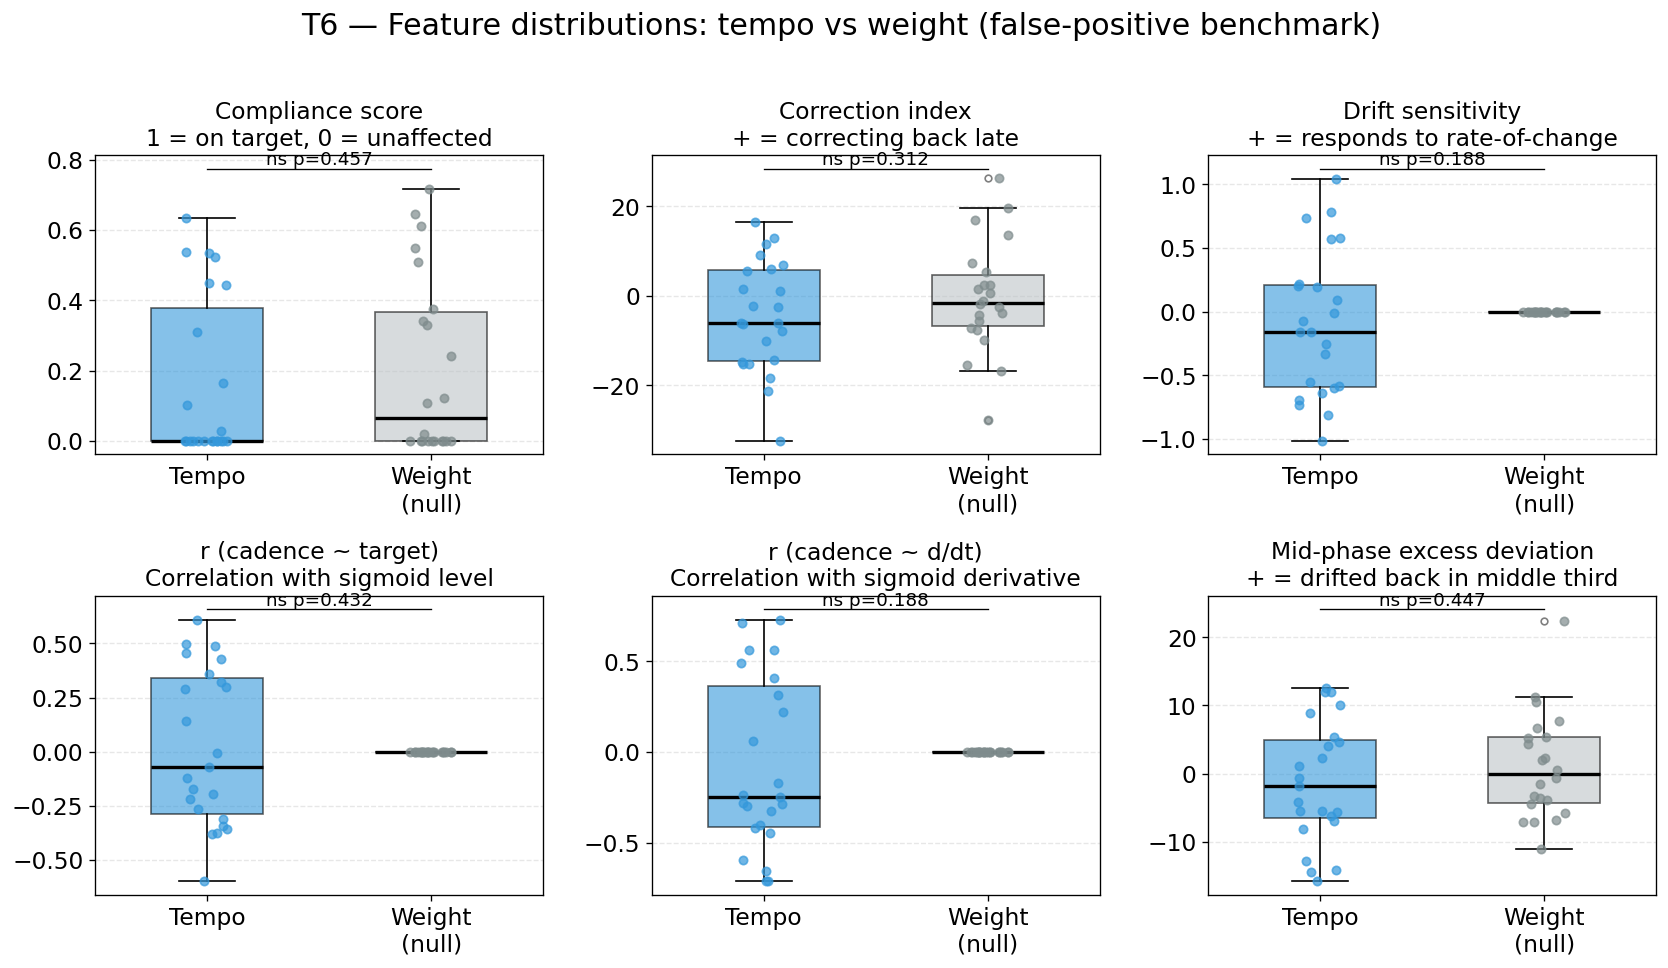


=== False positive analysis (weight data) ===
Score                       Tempo median  Weight median    p (MWU)   Sig
Compliance score                    0.00           0.06     0.4569    ns
Correction index                   -6.03          -1.58     0.3123    ns
Drift sensitivity                  -0.16           0.00     0.1880    ns
r (cadence ~ target)               -0.07           0.00     0.4324    ns
r (cadence ~ d/dt)                 -0.25           0.00     0.1880    ns
Mid-phase excess deviation          -1.76          -0.08     0.4469    ns


In [356]:
BENCHMARK_SCORES = [
    ("compliance_score",  "Compliance score",   "1 = on target, 0 = unaffected"),
    ("correction_index",  "Correction index",   "+ = correcting back late"),
    ("drift_sensitivity", "Drift sensitivity",  "+ = responds to rate-of-change"),
    ("r_level",           "r (cadence ~ target)",  "Correlation with sigmoid level"),
    ("r_deriv",           "r (cadence ~ d/dt)",    "Correlation with sigmoid derivative"),
    ("mid_excess",        "Mid-phase excess deviation", "+ = drifted back in middle third"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, (col, label, note) in zip(axes, BENCHMARK_SCORES):
    t_vals = df_tempo[col].dropna().values
    w_vals = df_weight[col].dropna().values

    bp = ax.boxplot(
        [t_vals, w_vals], positions=[0, 1], widths=0.5, patch_artist=True,
        medianprops=dict(color="black", lw=2),
        boxprops=dict(alpha=0.6),
        whiskerprops=dict(lw=1), capprops=dict(lw=1),
        flierprops=dict(marker="o", alpha=0.5, ms=4)
    )
    bp["boxes"][0].set_facecolor("#3498db")
    bp["boxes"][1].set_facecolor("#bdc3c7")

    # Individual points
    jit = np.random.default_rng(0).uniform(-0.1, 0.1, len(t_vals))
    ax.scatter(jit,       t_vals, color="#3498db", s=25, alpha=0.7, zorder=3)
    jit2 = np.random.default_rng(1).uniform(-0.1, 0.1, len(w_vals))
    ax.scatter(jit2 + 1,  w_vals, color="#7f8c8d", s=25, alpha=0.7, zorder=3)

    # Mann-Whitney U test (tempo vs weight)
    try:
        _, p = stats.mannwhitneyu(t_vals, w_vals, alternative="two-sided")
        sig = "***" if p<0.001 else ("**" if p<0.01 else ("*" if p<0.05 else "ns"))
        y_top = max(t_vals.max(), w_vals.max()) * 1.08
        ax.plot([0, 1], [y_top, y_top], color="black", lw=0.8)
        ax.text(0.5, y_top, f"{sig} p={p:.3f}", ha="center", va="bottom", fontsize=11)
    except Exception:
        pass

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Tempo", "Weight\n(null)"], fontsize=14)
    ax.set_title(f"{label}\n{note}", fontsize=14)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

fig.suptitle("T6 — Feature distributions: tempo vs weight (false-positive benchmark)",
             fontsize=18, y=1.01)
plt.tight_layout()
plt.show()

# False positive rates per score
print("\n=== False positive analysis (weight data) ===")
print(f"{'Score':<25} {'Tempo median':>14} {'Weight median':>14} {'p (MWU)':>10} {'Sig':>5}")
for col, label, _ in BENCHMARK_SCORES:
    t_v = df_tempo[col].dropna().values
    w_v = df_weight[col].dropna().values
    try:
        _, p = stats.mannwhitneyu(t_v, w_v, alternative="two-sided")
        sig = "***" if p<0.001 else ("**" if p<0.01 else ("*" if p<0.05 else "ns"))
    except:
        p, sig = float("nan"), "N/A"
    print(f"{label:<25} {np.median(t_v):>14.2f} {np.median(w_v):>14.2f} {p:>10.4f} {sig:>5}")

## Figure 3 — Individual trajectory viewer

Select a participant to see their cadence trajectory vs the target, the deviation `d(t)` shaded by phase, and their assigned profile with all three scores.

In [357]:
tempo_pids = sorted(_tempo_feat.keys())

pid_traj_sel = widgets.Dropdown(
    options=tempo_pids, value=tempo_pids[0] if tempo_pids else "",
    description="Participant:", style={"description_width": "90px"},
    layout=widgets.Layout(width="200px")
)
show_weight_traj = widgets.Checkbox(value=True, description="Overlay weight trajectory",
                                     layout=widgets.Layout(width="220px"))
out_fig3 = widgets.Output()

PHASE_BANDS = [
    (0,                    FADE_FRAC * 100,        "#3498db", "Ramp-in"),
    (FADE_FRAC * 100,      (1 - FADE_FRAC) * 100,  "#e67e22", "Plateau"),
    ((1 - FADE_FRAC) * 100, 100,                   "#27ae60", "Ramp-out"),
]

def _draw_fig3(_=None):
    out_fig3.clear_output(wait=True)
    pid  = pid_traj_sel.value
    feat = _tempo_feat.get(pid)
    if feat is None: return
    with out_fig3:
        # _make_trajectory_fig is defined in the export cell below;
        # run that cell first if you see a NameError here.
        fig = _make_trajectory_fig(feat)
        plt.show()

pid_traj_sel.observe(_draw_fig3, names="value")
display(widgets.HBox([pid_traj_sel]), out_fig3)
_draw_fig3()

Output()

In [342]:
## ── Batch export: per-session cadence + acceleration trajectories ─────────

def _make_trajectory_fig(feat):
    """
    Build the 4-panel trajectory figure for one participant and return it
    (without calling plt.show). Used both by the interactive viewer and the
    batch exporter so the plot logic is never duplicated.
    """
    profile = feat["profile"]
    color   = PROFILE_COLORS.get(profile, "#2c3e50")
    t_n     = feat["_t_norm"]
    cad     = feat["_cadence"]
    tgt     = feat["_target_abs"]
    base    = feat["baseline"]
    d_tgt   = feat["_deviation"]
    d_base  = feat["_d_baseline"]
    ts      = 1.0 if feat["direction"] != "slowing down" else -1.0

    ca_disp = _display_accel(feat.get("_cad_accel", np.zeros_like(t_n)))
    ta_raw  = np.asarray(feat.get("_target_accel", np.zeros_like(t_n)), dtype=float)
    ta_m    = np.abs(ta_raw).max()
    ta_disp = ta_raw / ta_m if ta_m > 1e-9 else ta_raw.copy()

    PHASE_BANDS_LOCAL = [
        (0,              FADE_FRAC*100,        "#3498db", "Ramp-in"),
        (FADE_FRAC*100,  (1-FADE_FRAC)*100,   "#e67e22", "Plateau"),
        ((1-FADE_FRAC)*100, 100,              "#27ae60", "Ramp-out"),
    ]

    fig, axes = plt.subplots(4, 1, figsize=(13, 11),
                              gridspec_kw={"height_ratios": [2, 1, 1, 1]},
                              sharex=True)
    fig.subplots_adjust(hspace=0.08)

    for ax in axes:
        for x0, x1, c, _ in PHASE_BANDS_LOCAL:
            ax.axvspan(x0, x1, alpha=0.05, color=c)

    ax1 = axes[0]
    ax1.axhline(base, color="#bdc3c7", lw=1.0, linestyle=":", label=f"Baseline ({base:.0f} SPM)")
    ax1.plot(t_n*100, tgt, color="#2c3e50", lw=1.4, linestyle="--", label="Target")
    ax1.plot(t_n*100, cad, color=color, lw=1.8, label=f"Cadence — {profile}")
    fw = _weight_feat.get(feat["pid"])
    if fw:
        ax1.plot(t_n*100, np.interp(t_n, fw["_t_norm"], fw["_cadence"]),
                 color="#95a5a6", lw=1.0, linestyle=":", alpha=0.7, label="Weight")
    ax1.set_ylabel("Cadence (SPM)", fontsize=14)
    ax1.legend(fontsize=11, loc="upper right")
    ax1.grid(linestyle="--", alpha=0.3)
    for x0, x1, c, lbl in PHASE_BANDS_LOCAL:
        ax1.axvline(x0, color=c, lw=0.8, linestyle=":", alpha=0.5)
        ax1.text((x0+x1)/2, ax1.get_ylim()[1], lbl, ha="center", va="top",
                 fontsize=11, color=c, alpha=0.8)
    score_txt = (
        f"Profile:         {profile}\n"
        f"Compliance:      {feat['compliance_score']:.2f}\n"
        f"Plateau-drop z:  {feat['plateau_drop_z']:+.2f} SD\n"
        f"Correct-early z: {feat['correct_early_z']:+.2f} SD\n"
        f"Correct-mid z:   {feat['correct_mid_z']:+.2f} SD\n"
        f"Opposite-late z: {feat['opposite_late_z']:+.2f} SD\n"
        f"r_cad_accel:     {feat['r_cad_accel']:+.2f}\n"
        f"Natural SD:      {feat['baseline_sd']:.1f} SPM"
    )
    ax1.text(0.02, 0.97, score_txt, transform=ax1.transAxes, fontsize=11, va="top",
             family="monospace", bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.88))

    ax2 = axes[1]
    ax2.fill_between(t_n*100, d_tgt, 0, where=d_tgt>0, alpha=0.35, color="#e74c3c")
    ax2.fill_between(t_n*100, d_tgt, 0, where=d_tgt<0, alpha=0.35, color="#3498db")
    ax2.plot(t_n*100, d_tgt, color="#2c3e50", lw=1.0)
    ax2.axhline(0, color="black", lw=0.8)
    ax2.set_ylabel("vs Target\n(SPM)", fontsize=13)
    ax2.grid(linestyle="--", alpha=0.3)

    ax3 = axes[2]
    c_col = "#27ae60" if ts > 0 else "#e74c3c"
    o_col = "#e74c3c" if ts > 0 else "#27ae60"
    wt = d_base * ts
    ax3.fill_between(t_n*100, wt, 0, where=wt>0, alpha=0.35, color=c_col, label="With target")
    ax3.fill_between(t_n*100, wt, 0, where=wt<0, alpha=0.35, color=o_col, label="Opposite")
    ax3.plot(t_n*100, wt, color="#2c3e50", lw=1.0)
    ax3.axhline(0, color="black", lw=0.8)
    ax3.set_ylabel("vs Baseline\n(signed, SPM)", fontsize=13)
    ax3.legend(fontsize=11, loc="upper right")
    ax3.grid(linestyle="--", alpha=0.3)

    ax4 = axes[3]
    ax4.plot(t_n*100, ta_disp, color="#2c3e50", lw=1.6, linestyle="--", alpha=0.8,
             label="Target accel (analytical)")
    ax4.plot(t_n*100, ca_disp, color=color, lw=1.4, alpha=0.85,
             label=f"Cadence accel  r={feat['r_cad_accel']:+.2f}")
    ax4.axhline(0, color="black", lw=0.8)
    aligned = (ca_disp * ta_disp) > 0
    opposed = (ca_disp * ta_disp) < 0
    ax4.fill_between(t_n*100, ca_disp, 0, where=aligned, alpha=0.20, color="#27ae60")
    ax4.fill_between(t_n*100, ca_disp, 0, where=opposed, alpha=0.20, color="#e74c3c")
    ax4.set_ylim(-1.4, 1.4)
    ax4.set_ylabel("Acceleration\n(normalised ±1)", fontsize=13)
    ax4.set_xlabel("Trial progress (%)", fontsize=14)
    ax4.legend(fontsize=11, loc="upper right")
    ax4.grid(linestyle="--", alpha=0.3)

    for ax in axes[1:]:
        for x0, _, c, _ in PHASE_BANDS_LOCAL:
            ax.axvline(x0, color=c, lw=0.8, linestyle=":", alpha=0.4)

    pid = feat["pid"]
    fig.suptitle(f"T6 — P{pid}  |  {feat['direction']}  |  {feat['order']}  |  {profile}",
                 fontsize=18, y=1.01)
    plt.tight_layout()
    return fig


def export_all_trajectories(save_dir=None):
    """Save a 4-panel trajectory PNG for every participant in tempo and weight sessions."""
    from pathlib import Path
    d = Path(save_dir or "exports/trajectories")
    d.mkdir(parents=True, exist_ok=True)

    all_feats = list(_tempo_feat.values()) + list(_weight_feat.values())
    for i, feat in enumerate(all_feats):
        pid     = feat["pid"]
        phase   = feat["phase"]
        profile = feat["profile"].replace(":", "_").replace(" ", "_")
        direction = feat["direction"].replace(" ", "_")
        fname   = d / f"{pid}_{phase}_{direction}_{profile}.png"
        fig     = _make_trajectory_fig(feat)
        fig.savefig(fname, dpi=150, bbox_inches="tight")
        plt.close(fig)
        print(f"  [{i+1}/{len(all_feats)}] Saved {fname.name}")

    print(f"\nDone — {len(all_feats)} figures saved to {d}/")


traj_export_btn    = widgets.Button(description="Export all trajectories",
                                     button_style="info",
                                     layout=widgets.Layout(width="200px"))
traj_export_status = widgets.Label("")

def _do_traj_export(_):
    traj_export_status.value = "Exporting…"
    export_all_trajectories()
    traj_export_status.value = "✓ Saved to exports/trajectories/"

traj_export_btn.on_click(_do_traj_export)
display(widgets.HBox([traj_export_btn]), traj_export_status)

Label(value='')

In [343]:
## ── Batch export: profile box plots ───────────────────────────────────────

BOX_FEATURES = [
    ("correct_early_z",  "Correct-early z\n(ramp-in tracking)"),
    ("plateau_drop_z",   "Plateau-drop z\n(drift-in key)"),
    ("opposite_late_z",  "Opposite-late z\n(fade-out / overcorrect)"),
    ("correct_mid_z",    "Correct-mid z\n(plateau tracking)"),
    ("compliance_score", "Compliance score\n(overall on-target)"),
]


def export_profile_boxplots(save_dir=None):
    from pathlib import Path
    d = Path(save_dir or "exports/profiles")
    d.mkdir(parents=True, exist_ok=True)

    profiles_present = list(dict.fromkeys(
        [r["profile"] for r in tempo_rows]   # preserve order of first appearance
    ))

    # ── Figure A: all profiles overview ─────────────────────────────────────
    ncols = len(BOX_FEATURES)
    fig_a, axes_a = plt.subplots(1, ncols, figsize=(4 * ncols, 6))
    fig_a.subplots_adjust(wspace=0.40)

    for ax, (col, label) in zip(axes_a, BOX_FEATURES):
        data_by_profile = []
        colors_by_profile = []
        tick_labels = []
        for prof in profiles_present:
            vals = [r[col] for r in tempo_rows if r["profile"] == prof
                    and col in r and not np.isnan(r[col])]
            if vals:
                data_by_profile.append(vals)
                colors_by_profile.append(PROFILE_COLORS.get(prof, "#aab7b8"))
                tick_labels.append(prof.replace(": ", ":\n"))

        if not data_by_profile:
            continue

        positions = list(range(len(data_by_profile)))
        bp = ax.boxplot(data_by_profile, positions=positions, widths=0.55,
                        patch_artist=True,
                        medianprops=dict(color="black", lw=2),
                        whiskerprops=dict(lw=1), capprops=dict(lw=1),
                        flierprops=dict(marker="o", ms=3, alpha=0.5))
        for patch, color in zip(bp["boxes"], colors_by_profile):
            patch.set_facecolor(color); patch.set_alpha(0.55)

        # Jitter individual points
        rng = np.random.default_rng(42)
        for xi, (vals, color) in enumerate(zip(data_by_profile, colors_by_profile)):
            jit = rng.uniform(-0.15, 0.15, len(vals))
            ax.scatter(np.array([xi]*len(vals)) + jit, vals,
                       color=color, s=20, alpha=0.7, zorder=3)

        ax.axhline(0, color="#bdc3c7", lw=0.8, linestyle="--")
        ax.set_xticks(positions)
        ax.set_xticklabels(tick_labels, fontsize=11, rotation=30, ha="right")
        ax.set_title(label, fontsize=14)
        ax.grid(axis="y", linestyle="--", alpha=0.3)

    fig_a.suptitle("T6 — Key features by behavioural profile (tempo sessions)",
                   fontsize=18, y=1.01)
    plt.tight_layout()
    path_a = d / "profile_features_overview.png"
    fig_a.savefig(path_a, dpi=150, bbox_inches="tight")
    plt.close(fig_a)
    print(f"  Saved {path_a.name}")

    # ── Figure B: per-profile detail ────────────────────────────────────────
    for prof in profiles_present:
        rows = [r for r in tempo_rows if r["profile"] == prof]
        if len(rows) < 2:
            continue

        fig_b, axes_b = plt.subplots(1, len(BOX_FEATURES),
                                      figsize=(3.5 * len(BOX_FEATURES), 5))
        fig_b.subplots_adjust(wspace=0.40)
        color = PROFILE_COLORS.get(prof, "#aab7b8")

        for ax, (col, label) in zip(axes_b, BOX_FEATURES):
            vals = [r[col] for r in rows if col in r and not np.isnan(r[col])]
            pids = [r["pid"] for r in rows if col in r and not np.isnan(r[col])]
            if not vals: continue

            ax.boxplot([vals], positions=[0], widths=0.5, patch_artist=True,
                       medianprops=dict(color="black", lw=2),
                       boxprops=dict(facecolor=color, alpha=0.45),
                       whiskerprops=dict(lw=1), capprops=dict(lw=1),
                       flierprops=dict(marker="o", ms=3))
            rng = np.random.default_rng(0)
            jit = rng.uniform(-0.12, 0.12, len(vals))
            ax.scatter(jit, vals, color=color, s=35, alpha=0.8, zorder=3)
            for j, (v, pid) in enumerate(zip(vals, pids)):
                ax.annotate(pid, (jit[j], v), fontsize=11, ha="center", va="bottom",
                            xytext=(0, 3), textcoords="offset points")

            ax.axhline(0, color="#bdc3c7", lw=0.8, linestyle="--")
            ax.set_xticks([]); ax.set_title(label, fontsize=14)
            ax.grid(axis="y", linestyle="--", alpha=0.3)

        fig_b.suptitle(f"T6 — Profile: {prof}  (n={len(rows)})",
                       fontsize=18, color=color)
        plt.tight_layout()
        safe = prof.replace(": ", "_").replace(" ", "_").replace("/", "_")
        path_b = d / f"profile_{safe}.png"
        fig_b.savefig(path_b, dpi=150, bbox_inches="tight")
        plt.close(fig_b)
        print(f"  Saved {path_b.name}")

    print(f"\nDone — profile plots saved to {d}/")


prof_export_btn    = widgets.Button(description="Export profile plots",
                                     button_style="warning",
                                     layout=widgets.Layout(width="180px"))
prof_export_status = widgets.Label("")

def _do_prof_export(_):
    prof_export_status.value = "Exporting…"
    export_profile_boxplots()
    prof_export_status.value = "✓ Saved to exports/profiles/"

prof_export_btn.on_click(_do_prof_export)
display(widgets.HBox([prof_export_btn]), prof_export_status)

Label(value='')

## Figure 4 — Profile grid

All participants belonging to a selected profile, shown in a grid for quick comparison.

In [344]:
profile_sel = widgets.Dropdown(
    options=list(PROFILE_COLORS.keys()),
    description="Profile:", style={"description_width": "70px"},
    layout=widgets.Layout(width="230px")
)
out_fig4 = widgets.Output()

def _draw_fig4(_=None):
    out_fig4.clear_output(wait=True)
    with out_fig4:
        prof  = profile_sel.value
        color = PROFILE_COLORS[prof]
        pids  = df_tempo[df_tempo["profile"] == prof]["pid"].tolist()
        if not pids:
            print(f"No participants with profile '{prof}'.")
            return
        ncols = min(4, len(pids))
        nrows = (len(pids) + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.5 * nrows),
                                  sharex=True, sharey=False)
        axes_flat = np.array(axes).flatten() if len(pids) > 1 else [axes]

        k = 8.0
        t_common = np.linspace(0, 1, 200)

        for ax, pid in zip(axes_flat, pids):
            feat = _tempo_feat.get(pid)
            if feat is None: ax.set_visible(False); continue
            t_n  = feat["_t_norm"]
            cad  = feat["_cadence"]
            tgt  = feat["_target_abs"]
            dev  = feat["_deviation"]
            ax.fill_between(t_n*100, dev, 0, where=dev>0, alpha=0.3, color="#e74c3c")
            ax.fill_between(t_n*100, dev, 0, where=dev<0, alpha=0.3, color="#3498db")
            ax.plot(t_n*100, dev, color="#2c3e50", lw=0.9)
            ax.axhline(0, color="black", lw=0.7)
            ax.set_title(f"P{pid}  cs={feat['compliance_score']:.2f}  ci={feat['correction_index']:+.0f}",
                         fontsize=13)
            ax.grid(linestyle="--", alpha=0.3)
            ax.tick_params(labelsize=7)

        for ax in axes_flat[len(pids):]:
            ax.set_visible(False)

        fig.supxlabel("Trial progress (%)", fontsize=14)
        fig.supylabel("Deviation from target (SPM)", fontsize=14)
        fig.suptitle(f"T6 — Profile: {prof}  (n={len(pids)})",
                     fontsize=18, color=color)
        plt.tight_layout()
        plt.show()

profile_sel.observe(_draw_fig4, names="value")
display(profile_sel, out_fig4)
_draw_fig4()

Dropdown(description='Profile:', layout=Layout(width='230px'), options=('Compliant', 'Follow-then-correct', 'D…

Output()

## Figure 5 — Summary table

All participants with their assigned profile and continuous scores. Sort columns by clicking the header.

In [345]:
import warnings
warnings.filterwarnings("ignore")

# ── Profile influence tier definition ───────────────────────────────────────
PROFILE_TIER = {
    "Compliant":            1,   # fully tracked target throughout
    "Comply + overcorrect": 2,   # tracked AND overshot opposite on return
    "Drift-sensitive":      3,   # responded to both ramp-in AND ramp-out
    "Drift-in sensitive":   4,   # clear ramp-in response + plateau drop
    "Follow-then-correct":  5,   # tracked early, consciously corrected
    "Fade-out sensitive":   6,   # only affected by return phase
    "Partial: compliance":  7,   # weak sustained movement in right direction
    "Partial: drift-in":    8,   # weak ramp-in + plateau drop signal
    "Partial: fade-out":    9,   # tiny opposite movement in ramp-out
    "No clear pattern":     10,  # no dominant tendency
    "Resistant":            11,  # no detectable effect
}

TIER_MEANING = {
    1:  "Fully tracked target throughout",
    2:  "Tracked AND overshot opposite on return",
    3:  "Responded to both ramp-in AND ramp-out transitions",
    4:  "Clear ramp-in response; dropped back in plateau",
    5:  "Tracked early, then consciously corrected back",
    6:  "Unaffected during main period; only return phase impacted",
    7:  "Weak sustained movement in correct direction",
    8:  "Weak ramp-in response with some plateau drop",
    9:  "Tiny opposite movement in ramp-out only",
    10: "No dominant tendency; genuinely flat/noisy",
    11: "No detectable effect throughout",
}

# Key thresholds used in classify_profile (for transparency column)
_THRESHOLDS = {
    "Compliant":            {"cs > 0.55": "compliance_score"},
    "Comply + overcorrect": {"ol_z > 0.5": "opposite_late_z", "ce/cm_z > 0.4": None},
    "Drift-sensitive":      {"ce_z > 0.3": "correct_early_z", "pd_z > 0.4": "plateau_drop_z", "ol_z > 0.3": "opposite_late_z"},
    "Drift-in sensitive":   {"ce_z > 0.40": "correct_early_z", "pd_z > 0.45": "plateau_drop_z", "cm_z < 0": "correct_mid_z"},
    "Follow-then-correct":  {"ci_z > 0.5": "correction_index_z"},
    "Fade-out sensitive":   {"ol_z > 0.5": "opposite_late_z", "ce_z < 0.4": "correct_early_z"},
    "Partial: drift-in":    {"ce_z > 0.25": "correct_early_z", "pd_z > 0.25": "plateau_drop_z", "cm_z < 0": "correct_mid_z"},
    "Partial: compliance":  {"cm_z > 0.15 or cs > 0.30": None},
    "Partial: fade-out":    {"ol_z > 0.35": "opposite_late_z"},
    "No clear pattern":     {"(fallthrough)": None},
    "Resistant":            {"cs < 0.20": "compliance_score"},
}


def compute_influence_score(row):
    """
    Composite influence score: max signal in any feature, normalised to [0,1].
    Reflects: 'how large was the biggest detected effect relative to natural variability?'
    """
    vals = [
        row.get("correct_early_z",  0.0),
        row.get("correct_mid_z",    0.0),
        row.get("opposite_late_z",  0.0),
        row.get("plateau_drop_z",   0.0),
        row.get("compliance_score", 0.0) * 3.0,  # scale cs to z-score range
    ]
    raw = max(vals) / 3.0   # normalise: 3 SD ≈ top of scale
    return float(np.clip(raw, 0.0, 1.0))


# ── Build enhanced summary ───────────────────────────────────────────────────
rows_enhanced = []
for r in tempo_rows:
    profile = r["profile"]
    tier    = PROFILE_TIER.get(profile, 99)
    iscore  = compute_influence_score(r)

    # Threshold distance: how far (in units of threshold) each key feature is
    # Positive = exceeded threshold (earns the current label or higher)
    ce_z  = r.get("correct_early_z",  0.0)
    pd_z  = r.get("plateau_drop_z",   0.0)
    ol_z  = r.get("opposite_late_z",  0.0)
    cm_z  = r.get("correct_mid_z",    0.0)
    cs    = r.get("compliance_score", 0.0)

    # Gap to next tier up: how much each feature would need to increase
    # to reach the next-highest unambiguous profile
    gap_to_drift_in = min(
        max(0, 0.40 - ce_z),  # need ce_z > 0.40
        max(0, 0.45 - pd_z),  # need pd_z > 0.45
    )

    rows_enhanced.append({
        "pid":             r["pid"],
        "direction":       r["direction"],
        "order":           r["order"],
        "tier":            tier,
        "profile":         profile,
        "influence_score": iscore,
        # Key z-scores
        "ce_z (ramp-in)":  ce_z,
        "pd_z (drop)":     pd_z,
        "ol_z (fade-out)": ol_z,
        "cm_z (plateau)":  cm_z,
        "compliance":      cs,
        # Gap to drift-in sensitive (unambiguous tier 4)
        "gap→drift-in":    round(gap_to_drift_in, 2),
    })

df_enhanced = pd.DataFrame(rows_enhanced).sort_values("influence_score", ascending=False)
df_enhanced["rank"] = range(1, len(df_enhanced) + 1)
df_enhanced = df_enhanced.set_index("rank")

def _style_enhanced(df):
    def _row_bg(row):
        color = PROFILE_COLORS.get(row["profile"], "#ffffff")
        return [f"background-color: {color}18" for _ in row]

    def _score_bar(val):
        """Green-to-grey background based on influence score."""
        if pd.isna(val): return ""
        green = int(39 + (1-val) * 180)
        return f"background-color: rgb(39,{green},70); color: white; font-weight: bold"

    def _z_color(val):
        """Blue tint for positive z, red for negative."""
        if pd.isna(val): return ""
        if val > 0.3: return "background-color: #d5f5e3"
        if val < -0.3: return "background-color: #fadbd8"
        return ""

    return (df.style
              .apply(_row_bg, axis=1)
              .applymap(_score_bar, subset=["influence_score"])
              .applymap(_z_color, subset=["ce_z (ramp-in)", "pd_z (drop)",
                                          "ol_z (fade-out)", "cm_z (plateau)"])
              .format({
                  "influence_score":  "{:.2f}",
                  "ce_z (ramp-in)":   "{:+.2f}",
                  "pd_z (drop)":      "{:+.2f}",
                  "ol_z (fade-out)":  "{:+.2f}",
                  "cm_z (plateau)":   "{:+.2f}",
                  "compliance":       "{:.2f}",
                  "gap→drift-in":     "{:.2f}",
              })
              .set_caption(
                  "Behavioural profiles — ranked by influence score (1 = most influenced). "
                  "Green cells = z-score exceeds 0.3 SD threshold. "
                  "gap→drift-in = how much ce_z/pd_z needs to increase to reach Tier 4."
              ))

print("=== PROFILE INFLUENCE TIERS ===")
print(f"{'Tier':<5} {'Profile':<25} {'Meaning'}")
for tier_n in sorted(TIER_MEANING):
    prof = [p for p, t in PROFILE_TIER.items() if t == tier_n]
    p_str = prof[0] if prof else "—"
    print(f"  {tier_n:<3}  {p_str:<25} {TIER_MEANING[tier_n]}")

print(f"\n{'─'*70}")
print("Table sorted by influence_score descending (rank 1 = most influenced):\n")
_style_enhanced(df_enhanced)

=== PROFILE INFLUENCE TIERS ===
Tier  Profile                   Meaning
  1    Compliant                 Fully tracked target throughout
  2    Comply + overcorrect      Tracked AND overshot opposite on return
  3    Drift-sensitive           Responded to both ramp-in AND ramp-out transitions
  4    Drift-in sensitive        Clear ramp-in response; dropped back in plateau
  5    Follow-then-correct       Tracked early, then consciously corrected back
  6    Fade-out sensitive        Unaffected during main period; only return phase impacted
  7    Partial: compliance       Weak sustained movement in correct direction
  8    Partial: drift-in         Weak ramp-in response with some plateau drop
  9    Partial: fade-out         Tiny opposite movement in ramp-out only
  10   No clear pattern          No dominant tendency; genuinely flat/noisy
  11   Resistant                 No detectable effect throughout

──────────────────────────────────────────────────────────────────────
Table sorted

,pid,direction,order,tier,profile,influence_score,ce_z (ramp-in),pd_z (drop),ol_z (fade-out),cm_z (plateau),compliance,gap→drift-in
rank,,,,,,,,,,,,
1,30,speeding up,tempo first,2,Comply + overcorrect,1.00,+2.07,+25.98,+30.60,-23.92,0.00,0.00
2,40,speeding up,weight first,7,Partial: compliance,0.92,+0.15,-2.62,-1.47,+2.77,0.52,0.25
3,32,slowing down,weight first,9,Partial: fade-out,0.81,-0.29,+2.32,+2.44,-2.60,0.00,0.00
4,11,speeding up,weight first,2,Comply + overcorrect,0.79,+1.24,+2.10,+2.37,-0.86,0.00,0.00
5,33,speeding up,weight first,9,Partial: fade-out,0.77,+0.00,+2.10,+2.32,-2.09,0.00,0.00
6,31,slowing down,weight first,1,Compliant,0.74,+0.09,-2.12,-1.13,+2.22,0.63,0.31
7,38,slowing down,tempo first,7,Partial: compliance,0.73,-0.08,-2.27,-2.66,+2.19,0.54,0.48
8,19,speeding up,weight first,9,Partial: fade-out,0.68,-0.69,+0.42,+2.04,-1.11,0.00,0.03
9,13,speeding up,tempo first,5,Follow-then-correct,0.54,+0.60,-0.89,-3.03,+1.49,0.54,0.00


## Influence ranking

**Left**: every participant ranked from most to least influenced (bar length = influence score, colour = profile).  
**Right**: each profile tier's n, median influence score, and median key z-scores — shows the expected feature pattern for each profile and confirms the tier ordering makes sense.

`gap→drift-in` = 0 means the participant already meets all Drift-in sensitive thresholds; a positive value shows how much `ce_z` or `pd_z` still needs to increase to earn that label.

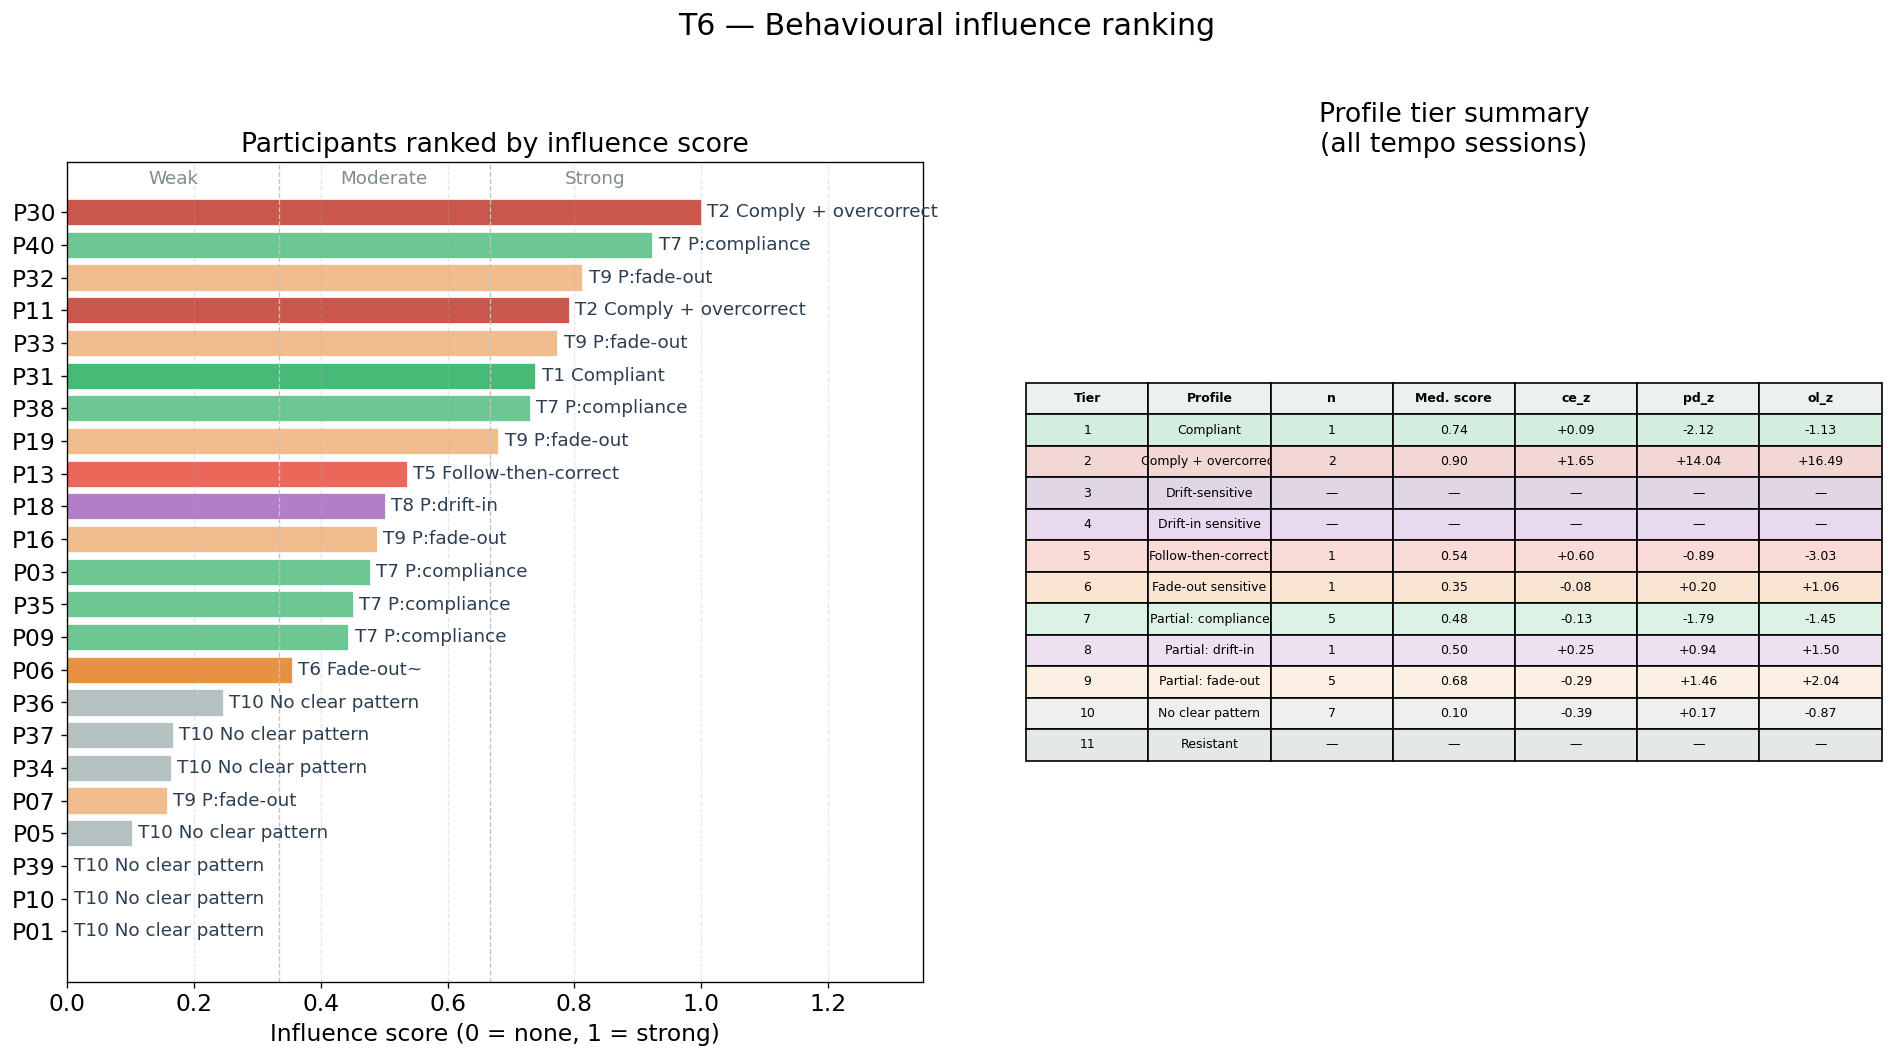

In [346]:
fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(df_enhanced) * 0.38)))
fig.subplots_adjust(wspace=0.45)

# ── Panel A: participant ranking bar chart ───────────────────────────────────
ax_left = axes[0]
df_sorted = df_enhanced.sort_values("influence_score", ascending=True)  # bottom-up for horizontal bar

bar_colors = [PROFILE_COLORS.get(p, "#aab7b8") for p in df_sorted["profile"]]
bars = ax_left.barh(
    [f"P{pid}" for pid in df_sorted["pid"]],
    df_sorted["influence_score"],
    color=bar_colors, edgecolor="white", linewidth=0.5, alpha=0.85
)

# Annotate with profile name
for bar, (_, row) in zip(bars, df_sorted.iterrows()):
    short = row["profile"].replace("Partial: ", "P:").replace(" sensitive", "~")
    ax_left.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f"T{row['tier']} {short}", va="center", fontsize=11, color="#2c3e50")

ax_left.set_xlim(0, 1.35)
ax_left.set_xlabel("Influence score (0 = none, 1 = strong)", fontsize=14)
ax_left.set_title("Participants ranked by influence score", fontsize=16)
ax_left.axvline(1/3, color="#bdc3c7", lw=0.8, linestyle="--")
ax_left.axvline(2/3, color="#bdc3c7", lw=0.8, linestyle="--")
ax_left.text(1/6, ax_left.get_ylim()[1]*0.99, "Weak", ha="center", va="top", fontsize=11, color="#7f8c8d")
ax_left.text(0.5,  ax_left.get_ylim()[1]*0.99, "Moderate", ha="center", va="top", fontsize=11, color="#7f8c8d")
ax_left.text(5/6,  ax_left.get_ylim()[1]*0.99, "Strong", ha="center", va="top", fontsize=11, color="#7f8c8d")
ax_left.grid(axis="x", linestyle="--", alpha=0.3)

# ── Panel B: profile tier summary table ─────────────────────────────────────
ax_right = axes[1]
ax_right.axis("off")

tier_summary_rows = []
for tier_n in sorted(PROFILE_TIER.values()):
    profs_in_tier = [p for p, t in PROFILE_TIER.items() if t == tier_n]
    if not profs_in_tier: continue
    prof = profs_in_tier[0]
    subset = df_enhanced[df_enhanced["profile"] == prof]
    n = len(subset)
    if n == 0:
        tier_summary_rows.append([
            tier_n, prof[:22], "—", "—", "—", "—", "—"
        ])
    else:
        tier_summary_rows.append([
            tier_n,
            prof[:22],
            str(n),
            f"{subset['influence_score'].median():.2f}",
            f"{subset['ce_z (ramp-in)'].median():+.2f}",
            f"{subset['pd_z (drop)'].median():+.2f}",
            f"{subset['ol_z (fade-out)'].median():+.2f}",
        ])

col_labels = ["Tier", "Profile", "n", "Med. score", "ce_z", "pd_z", "ol_z"]
tbl = ax_right.table(
    cellText=tier_summary_rows,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(7.5)
tbl.scale(1, 1.55)

# Colour the tier rows by profile colour
for (row_idx, col_idx), cell in tbl.get_celld().items():
    if row_idx == 0:
        cell.set_facecolor("#ecf0f1")
        cell.set_text_props(fontweight="bold")
    elif row_idx <= len(tier_summary_rows):
        prof_name = tier_summary_rows[row_idx - 1][1]
        full_prof = next((p for p in PROFILE_COLORS if p.startswith(prof_name[:10])), None)
        if full_prof:
            color = PROFILE_COLORS[full_prof]
            # Hex to RGB with 20% alpha on white
            r, g, b = int(color[1:3],16), int(color[3:5],16), int(color[5:7],16)
            cell.set_facecolor(f"#{r+int((255-r)*0.8):02x}{g+int((255-g)*0.8):02x}{b+int((255-b)*0.8):02x}")

ax_right.set_title("Profile tier summary\n(all tempo sessions)", fontsize=16)

fig.suptitle("T6 — Behavioural influence ranking", fontsize=18, y=1.01)
plt.tight_layout()
plt.show()

In [347]:
fig5_export_btn    = widgets.Button(description="Export Figure 5",
                                     button_style="info",
                                     layout=widgets.Layout(width="160px"))
fig5_export_status = widgets.Label("")

def _do_fig5_export(_):
    from pathlib import Path
    d = Path("exports/figure5")
    d.mkdir(parents=True, exist_ok=True)
    fig5_export_status.value = "Exporting…"

    # ── 1. Ranking chart (matplotlib) → PNG ─────────────────────────────────
    fig_r, axes_r = plt.subplots(1, 2, figsize=(16, max(6, len(df_enhanced) * 0.38)))
    fig_r.subplots_adjust(wspace=0.45)

    ax_l = axes_r[0]
    df_s = df_enhanced.sort_values("influence_score", ascending=True)
    bar_cols = [PROFILE_COLORS.get(p, "#aab7b8") for p in df_s["profile"]]
    bars = ax_l.barh([f"P{pid}" for pid in df_s["pid"]],
                     df_s["influence_score"],
                     color=bar_cols, edgecolor="white", linewidth=0.5, alpha=0.85)
    for bar, (_, row) in zip(bars, df_s.iterrows()):
        short = row["profile"].replace("Partial: ", "P:").replace(" sensitive", "~")
        ax_l.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                  f"T{row['tier']} {short}", va="center", fontsize=11, color="#2c3e50")
    ax_l.set_xlim(0, 1.35); ax_l.set_xlabel("Influence score", fontsize=14)
    ax_l.set_title("Participants ranked by influence score", fontsize=16)
    ax_l.axvline(1/3, color="#bdc3c7", lw=0.8, linestyle="--")
    ax_l.axvline(2/3, color="#bdc3c7", lw=0.8, linestyle="--")
    ax_l.grid(axis="x", linestyle="--", alpha=0.3)

    ax_r = axes_r[1]; ax_r.axis("off")
    tier_rows = []
    for tn in sorted(PROFILE_TIER.values()):
        prof = next((p for p,t in PROFILE_TIER.items() if t==tn), None)
        if not prof: continue
        sub = df_enhanced[df_enhanced["profile"] == prof]
        n = len(sub)
        tier_rows.append([tn, prof[:22], str(n) if n else "—",
                          f"{sub['influence_score'].median():.2f}" if n else "—",
                          f"{sub['ce_z (ramp-in)'].median():+.2f}" if n else "—",
                          f"{sub['pd_z (drop)'].median():+.2f}" if n else "—",
                          f"{sub['ol_z (fade-out)'].median():+.2f}" if n else "—"])
    tbl = ax_r.table(cellText=tier_rows,
                     colLabels=["Tier","Profile","n","Med. score","ce_z","pd_z","ol_z"],
                     cellLoc="center", loc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(7.5); tbl.scale(1, 1.55)
    ax_r.set_title("Profile tier summary", fontsize=16)
    fig_r.suptitle("T6 — Behavioural influence ranking", fontsize=18, y=1.01)
    plt.tight_layout()
    fig_r.savefig(d / "influence_ranking_chart.png", dpi=150, bbox_inches="tight")
    plt.close(fig_r)

    # ── 2. Table → CSV ───────────────────────────────────────────────────────
    csv_path = d / "influence_table.csv"
    df_enhanced.to_csv(csv_path)

    # ── 3. Table → HTML (coloured version) ──────────────────────────────────
    html = _style_enhanced(df_enhanced).to_html()
    html_path = d / "influence_table.html"
    html_path.write_text(
        f"<html><head><meta charset='utf-8'>"
        f"<style>body{{font-family:sans-serif;padding:20px}}"
        f"table{{border-collapse:collapse}} td,th{{padding:6px 10px;border:1px solid #ddd}}</style>"
        f"</head><body>{html}</body></html>",
        encoding="utf-8"
    )

    fig5_export_status.value = "✓ Saved to exports/figure5/"
    print(f"Saved:\n  {d/'influence_ranking_chart.png'}\n  {csv_path}\n  {html_path}")

fig5_export_btn.on_click(_do_fig5_export)
display(widgets.HBox([fig5_export_btn]), fig5_export_status)

Label(value='')

## Threshold explorer

Adjust classification thresholds interactively and see how the profile assignments change, along with the false-positive rate on weight data.

In [348]:
cs_thresh  = widgets.FloatSlider(min=0.1, max=0.9, step=0.05, value=0.55,
                                  description="Compliant cs>",
                                  style={"description_width": "160px"},
                                  layout=widgets.Layout(width="420px"))
ol_thresh  = widgets.FloatSlider(min=0.0, max=2.0, step=0.05, value=0.50,
                                  description="Fade-out ol_z>",
                                  style={"description_width": "160px"},
                                  layout=widgets.Layout(width="420px"))
ce_thresh  = widgets.FloatSlider(min=0.0, max=1.5, step=0.05, value=0.40,
                                  description="Correct-early ce_z>",
                                  style={"description_width": "160px"},
                                  layout=widgets.Layout(width="420px"))
cm_thresh  = widgets.FloatSlider(min=0.0, max=1.5, step=0.05, value=0.40,
                                  description="Correct-mid cm_z>",
                                  style={"description_width": "160px"},
                                  layout=widgets.Layout(width="420px"))
ci_thresh  = widgets.FloatSlider(min=0.0, max=2.0, step=0.05, value=0.50,
                                  description="F-t-C ci_z>",
                                  style={"description_width": "160px"},
                                  layout=widgets.Layout(width="420px"))
res_thresh = widgets.FloatSlider(min=0.0, max=0.5, step=0.05, value=0.25,
                                  description="Resistant cs<",
                                  style={"description_width": "160px"},
                                  layout=widgets.Layout(width="420px"))
out_thresh = widgets.Output()


def _reclassify(feats, cs_t, ol_t, ce_t, cm_t, ci_t, res_t):
    profiles = []
    for f in feats:
        ol_z = f.get("opposite_late_z", 0.0)
        ce_z = f.get("correct_early_z", 0.0)
        cm_z = f.get("correct_mid_z",   0.0)
        ci_z = f.get("correction_index_z", 0.0)
        ed_z = f.get("early_dev_z", 0.0)
        me_z = f.get("mid_excess_z", 0.0)
        cs   = f.get("compliance_score", 0.0)
        ds   = f.get("drift_sensitivity", 0.0)
        nc   = f.get("n_crossings", 0)

        if ol_z > ol_t and abs(cm_z) < cm_t and ce_z < ce_t:
            profiles.append("Fade-out sensitive")
        elif ol_z > ol_t and (ce_z > ce_t or cm_z > cm_t):
            profiles.append("Comply + overcorrect")
        elif cs > cs_t:
            profiles.append("Compliant")
        elif ci_z > ci_t and abs(ed_z) < ce_t and nc >= 1:
            profiles.append("Follow-then-correct")
        elif ds > 0.25 and me_z > 0.4:
            profiles.append("Drift-sensitive")
        elif cs < res_t and abs(ol_z) < 0.35:
            profiles.append("Resistant")
        else:
            profiles.append("Mixed")
    return profiles


def _draw_thresh(_=None):
    out_thresh.clear_output(wait=True)
    t_prof = _reclassify(tempo_rows,  cs_thresh.value, ol_thresh.value,
                          ce_thresh.value, cm_thresh.value, ci_thresh.value, res_thresh.value)
    w_prof = _reclassify(weight_rows, cs_thresh.value, ol_thresh.value,
                          ce_thresh.value, cm_thresh.value, ci_thresh.value, res_thresh.value)

    fp_rate = sum(1 for p in w_prof if p != "Resistant") / max(len(w_prof), 1) * 100

    with out_thresh:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        from collections import Counter
        for ax, (profs, title) in zip(axes, [
            (t_prof, "Tempo — profile assignments"),
            (w_prof, f"Weight — false positives ({fp_rate:.0f}% non-Resistant)"),
        ]):
            counts = Counter(profs)
            labels = list(PROFILE_COLORS.keys())
            vals   = [counts.get(l, 0) for l in labels]
            colors = [PROFILE_COLORS[l] for l in labels]
            bars   = ax.bar(labels, vals, color=colors, alpha=0.7, edgecolor="white")
            for bar, v in zip(bars, vals):
                if v: ax.text(bar.get_x() + bar.get_width()/2, v + 0.05, str(v),
                              ha="center", va="bottom", fontsize=14)
            ax.set_ylabel("Count"); ax.set_title(title, fontsize=16)
            ax.tick_params(axis="x", rotation=20)
            ax.grid(axis="y", linestyle="--", alpha=0.3)

        fp_color = "#e74c3c" if fp_rate > 30 else "#27ae60"
        plt.suptitle(f"Threshold explorer (z-score units)  |  Weight FP rate: {fp_rate:.0f}%",
                     fontsize=18, color=fp_color)
        plt.tight_layout()
        plt.show()

for w in (cs_thresh, ol_thresh, ce_thresh, cm_thresh, ci_thresh, res_thresh):
    w.observe(_draw_thresh, names="value")
display(cs_thresh, ol_thresh, ce_thresh, cm_thresh, ci_thresh, res_thresh, out_thresh)
_draw_thresh()

FloatSlider(value=0.55, description='Compliant cs>', layout=Layout(width='420px'), max=0.9, min=0.1, step=0.05…

FloatSlider(value=0.5, description='Fade-out ol_z>', layout=Layout(width='420px'), max=2.0, step=0.05, style=S…

FloatSlider(value=0.4, description='Correct-early ce_z>', layout=Layout(width='420px'), max=1.5, step=0.05, st…

FloatSlider(value=0.4, description='Correct-mid cm_z>', layout=Layout(width='420px'), max=1.5, step=0.05, styl…

FloatSlider(value=0.5, description='F-t-C ci_z>', layout=Layout(width='420px'), max=2.0, step=0.05, style=Slid…

FloatSlider(value=0.25, description='Resistant cs<', layout=Layout(width='420px'), max=0.5, step=0.05, style=S…

Output()

## Permutation test — behaviour categorisation validity

Tests whether the classifier detects real manipulation-driven signal rather than chance
patterns in natural cadence variability.

**Method: cyclic time-shift permutation**
For each session the normalised time axis is shifted by a random offset
(`t_eff = (t_norm + offset) % 1.0`) before computing phase features.
This preserves the cadence distribution and autocorrelation structure but breaks
the alignment between gait responses and phase labels — creating a null distribution.

**Four conditions compared:**
- Real tempo sessions (should show elevated unambiguous rates)
- Permuted tempo — null distribution for the tempo classifier
- Real weight sessions — cross-condition benchmark (tempo classifier applied to weight data)
- Permuted weight — null distribution for the weight cross-condition

The functions `run_tempo_permutation_test` and `run_weight_permutation_test` are
**self-contained**: pass any `data_dir` and `pid_list` to apply them to new datasets.

In [349]:
# ─────────────────────────────────────────────────────────────────────────────
# Permutation test — behaviour categorisation
# ─────────────────────────────────────────────────────────────────────────────
# run_tempo_permutation_test() and run_weight_permutation_test() are
# self-contained: pass any data_dir and pid_list to reuse on new datasets.
# ─────────────────────────────────────────────────────────────────────────────

N_PERM = 500


def _features_from_shifted_time(t_norm, cad, baseline, baseline_sd,
                                 target_sign, offset):
    """
    Recompute all classification features after a cyclic shift of the time axis.
    Cadence values are unchanged; only the mapping to phase labels is randomised.
    """
    t_eff = (t_norm + offset) % 1.0

    e_mask = t_eff <= FADE_FRAC
    m_mask = (t_eff > FADE_FRAC) & (t_eff <= 1.0 - FADE_FRAC)
    l_mask = t_eff > 1.0 - FADE_FRAC

    d_baseline = cad - baseline

    def _pm(arr, mask):
        return float(arr[mask].mean()) if mask.sum() > 0 else 0.0

    early_base = _pm(d_baseline, e_mask)
    mid_base   = _pm(d_baseline, m_mask)
    late_base  = _pm(d_baseline, l_mask)

    def _z(x):
        return x / baseline_sd

    correct_early_z = _z(target_sign * early_base)
    correct_mid_z   = _z(target_sign * mid_base)
    opposite_late_z = _z(-target_sign * late_base)
    plateau_drop_z  = correct_early_z - correct_mid_z

    # Target trajectory on the shifted axis (for compliance score + r values)
    target_pct = _trapezoid_target(t_eff, target_sign)
    target_abs = baseline * (1 + target_pct / 100.0)
    d_target   = cad - target_abs

    target_amplitude = baseline * 0.08 + 1e-6
    compliance_score = float(np.clip(
        1.0 - np.abs(d_target).mean() / target_amplitude, 0, 1))

    early_dev = _pm(d_target, e_mask)
    mid_dev   = _pm(d_target, m_mask)
    late_dev  = _pm(d_target, l_mask)

    correction_index   = float(late_dev - early_dev)
    correction_index_z = _z(correction_index)
    mid_excess_z       = _z(mid_dev - (early_dev + late_dev) / 2.0)
    early_dev_z        = _z(early_dev)

    if cad.std() > 1e-6 and target_pct.std() > 1e-6:
        r_level = float(np.corrcoef(cad, target_pct)[0, 1])
        tg      = np.gradient(target_pct, t_eff)
        r_deriv = float(np.corrcoef(cad, tg)[0, 1]) if tg.std() > 1e-6 else 0.0
    else:
        r_level = r_deriv = 0.0

    n_crossings = int(np.sum(np.diff(np.sign(d_target)) != 0))

    return {
        "compliance_score":   compliance_score,
        "correct_early_z":    correct_early_z,
        "correct_mid_z":      correct_mid_z,
        "opposite_late_z":    opposite_late_z,
        "plateau_drop_z":     plateau_drop_z,
        "correction_index_z": correction_index_z,
        "early_dev_z":        early_dev_z,
        "mid_excess_z":       mid_excess_z,
        "r_level":            r_level,
        "r_deriv":            r_deriv,
        "n_crossings":        n_crossings,
        "drift_sensitivity":  r_deriv - r_level,
    }


def run_tempo_permutation_test(data_dir, pid_list, n_perm=N_PERM, seed=42):
    """
    Cyclic time-shift permutation test for the tempo behaviour classifier.

    For each participant, loads their tempo cadence, then runs n_perm random
    time-axis shifts and classifies each, building a null distribution.

    Parameters
    ----------
    data_dir : Path or str
        Root data directory containing one sub-folder per participant.
    pid_list : list of str
        Participant IDs to include.
    n_perm : int
        Number of random shifts per participant (default 500).
    seed : int
        RNG seed for reproducibility.

    Returns
    -------
    list of str
        Profile labels from all permuted sessions
        (length = n_participants_with_data * n_perm).
    """
    rng  = np.random.default_rng(seed)
    cats = []

    for pid in pid_list:
        order, direction = get_participant_meta(pid)
        if not direction:
            continue

        df = parse_pressure_file(
            Path(data_dir) / pid / f"{pid}_pressure_tempo.csv")
        if df.empty:
            continue

        baseline = compute_smart_baseline(pid)
        if baseline is None:
            continue

        baseline_sd = get_weight_cadence_sd(pid, window_s=PHASE_WINDOW_S)
        grid, cad   = _rolling_cadence(df, window_s=PHASE_WINDOW_S)
        if len(grid) < 20:
            continue

        t_norm      = grid / grid[-1]
        target_sign = 1.0 if direction != "slowing down" else -1.0

        for _ in range(n_perm):
            offset = float(rng.uniform(0, 1))
            feat   = _features_from_shifted_time(
                t_norm, cad, float(baseline), baseline_sd, target_sign, offset)
            cats.append(classify_profile(feat))

    return cats


def run_weight_permutation_test(data_dir, pid_list, n_perm=N_PERM, seed=43):
    """
    Cyclic time-shift permutation test applied to weight sessions.

    Uses the same tempo classifier — establishes the cross-condition null rate
    (how often the tempo classifier fires on data with no tempo manipulation).

    Parameters / Returns: same as run_tempo_permutation_test.
    """
    rng  = np.random.default_rng(seed)
    cats = []

    for pid in pid_list:
        order, direction = get_participant_meta(pid)
        if not direction:
            continue

        df = parse_pressure_file(
            Path(data_dir) / pid / f"{pid}_pressure_weight.csv")
        if df.empty:
            continue

        baseline = compute_smart_baseline(pid)
        if baseline is None:
            continue

        baseline_sd = get_weight_cadence_sd(pid, window_s=PHASE_WINDOW_S)
        grid, cad   = _rolling_cadence(df, window_s=PHASE_WINDOW_S)
        if len(grid) < 20:
            continue

        t_norm      = grid / grid[-1]
        target_sign = 1.0 if direction != "slowing down" else -1.0

        for _ in range(n_perm):
            offset = float(rng.uniform(0, 1))
            feat   = _features_from_shifted_time(
                t_norm, cad, float(baseline), baseline_sd, target_sign, offset)
            cats.append(classify_profile(feat))

    return cats


# ── Run ───────────────────────────────────────────────────────────────────────
_perm_pids = df_tempo["pid"].tolist()
print(f"Running permutation tests  (n_perm={N_PERM} × {len(_perm_pids)} participants)…")

perm_tempo_cats  = run_tempo_permutation_test(DATA_DIR, _perm_pids, N_PERM)
perm_weight_cats = run_weight_permutation_test(DATA_DIR, _perm_pids, N_PERM)

print(f"Done.  Tempo permutations: {len(perm_tempo_cats)} | "
      f"Weight permutations: {len(perm_weight_cats)}")


Running permutation tests  (n_perm=500 × 23 participants)…
Done.  Tempo permutations: 11500 | Weight permutations: 11000


PERMUTATION TEST — BEHAVIOUR CATEGORISATION
Profile                             Real tempo  Perm. tempo (null)         Real weight  Perm. weight (null
------------------------------------------------------------------------
Compliant                     1 (   4%)  468 (   4%)    3 (  14%)  1019 (   9%)
Comply + overcorrect          2 (   9%)  789 (   7%)    0 (   0%)  286 (   3%)
Drift-sensitive               0 (   0%)   59 (   1%)    0 (   0%)  119 (   1%)
Drift-in sensitive            0 (   0%)  619 (   5%)    0 (   0%)  319 (   3%)
Follow-then-correct           1 (   4%)  404 (   4%)    0 (   0%)  332 (   3%)
Fade-out sensitive            1 (   4%)  964 (   8%)    1 (   5%)  999 (   9%)
Partial: drift-in             1 (   4%)  154 (   1%)    0 (   0%)  232 (   2%)
Partial: compliance           5 (  22%)  2868 (  25%)    9 (  41%)  3327 (  30%)
Partial: fade-out             5 (  22%)  2909 (  25%)    3 (  14%)  3082 (  28%)
No clear pattern              7 (  30%)  2264 (  20%)    6 (

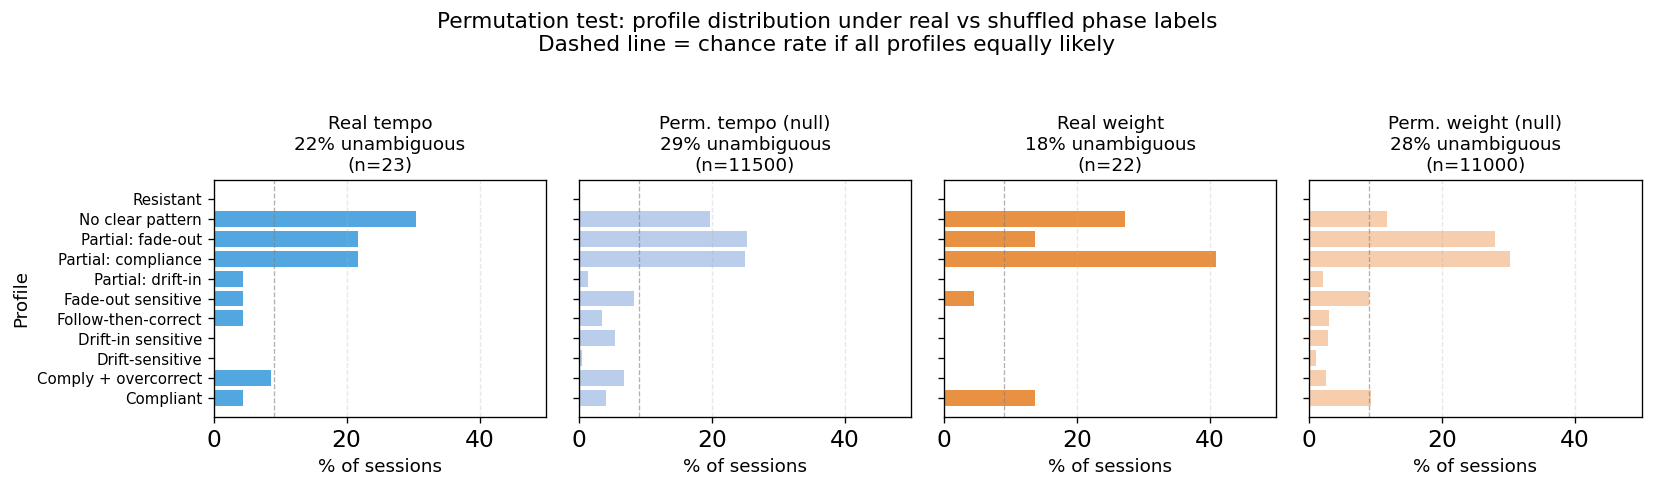

In [350]:
from collections import Counter
from scipy import stats as _scs

# Profile order for display (most to least influenced)
_PERM_PROFILE_ORDER = [
    "Compliant", "Comply + overcorrect", "Drift-sensitive",
    "Drift-in sensitive", "Follow-then-correct", "Fade-out sensitive",
    "Partial: drift-in", "Partial: compliance", "Partial: fade-out",
    "No clear pattern", "Resistant",
]
_AMBIGUOUS = {"No clear pattern", "Resistant",
              "Partial: drift-in", "Partial: compliance", "Partial: fade-out"}


def _cat_pct(cats, profile_order=_PERM_PROFILE_ORDER):
    c = Counter(cats)
    n = len(cats)
    return {k: (c.get(k, 0), 100 * c.get(k, 0) / n if n else 0)
            for k in profile_order}


def _unamb(cats):
    u = sum(1 for c in cats if c not in _AMBIGUOUS)
    return u, 100 * u / len(cats) if cats else 0


real_tempo_cats  = df_tempo["profile"].tolist()
real_weight_cats = df_weight["profile"].tolist()

COLS = [
    ("Real tempo",         real_tempo_cats,  len(real_tempo_cats)),
    ("Perm. tempo (null)", perm_tempo_cats,  len(perm_tempo_cats)),
    ("Real weight",        real_weight_cats, len(real_weight_cats)),
    ("Perm. weight (null)",perm_weight_cats, len(perm_weight_cats)),
]

# ── Console table ─────────────────────────────────────────────────────────────
print("=" * 72)
print("PERMUTATION TEST — BEHAVIOUR CATEGORISATION")
print("=" * 72)
hdr = f"{'Profile':<26}"
for lbl, _, n in COLS:
    hdr += f"  {lbl[:18]:>18}"
print(hdr)
print("-" * 72)
for prof in _PERM_PROFILE_ORDER:
    row = f"{prof:<26}"
    for _, cats, n in COLS:
        cnt, pct = _cat_pct(cats)[prof]
        row += f"  {cnt:>3} ({pct:4.0f}%)"
    print(row)
print("-" * 72)
row = f"{'Unambiguous total':<26}"
for _, cats, _ in COLS:
    u, upct = _unamb(cats)
    row += f"  {u:>3} ({upct:4.0f}%)"
print(row)

# ── Binomial test: real tempo vs permuted null ────────────────────────────────
real_u, real_upct     = _unamb(real_tempo_cats)
null_rate             = _unamb(perm_tempo_cats)[1] / 100
n_sess                = len(real_tempo_cats)
p_binom = _scs.binomtest(real_u, n_sess, p=null_rate,
                          alternative="greater").pvalue
print(f"\nBinomial test (real tempo unambiguous rate vs permuted null):")
print(f"  Real:      {real_u}/{n_sess}  ({real_upct:.0f}%)")
print(f"  Null rate: {null_rate*100:.1f}%  (from {len(perm_tempo_cats)} permutations)")
sig = "  *" if p_binom < 0.05 else "  (ns)"
print(f"  p = {p_binom:.4f}{sig}")

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
fig.subplots_adjust(wspace=0.08)

BAR_COLS = ["#3498db", "#aec6e8", "#e67e22", "#f5c6a0"]
for ax, (lbl, cats, _), color in zip(axes, COLS, BAR_COLS):
    rates = _cat_pct(cats)
    pcts  = [rates[p][1] for p in _PERM_PROFILE_ORDER]
    bars  = ax.barh(_PERM_PROFILE_ORDER, pcts, color=color, alpha=0.85)
    u, upct = _unamb(cats)
    ax.set_title(f"{lbl}\n{upct:.0f}% unambiguous\n(n={len(cats)})",
                 fontsize=11, color="black")
    ax.set_xlim(0, max(50, max(pcts) + 5))
    ax.axvline(100 / len(_PERM_PROFILE_ORDER), color="gray",
               lw=0.8, ls="--", alpha=0.6, label="Chance (equal)")
    ax.set_xlabel("% of sessions", fontsize=11)
    ax.tick_params(axis="y", labelsize=9)
    ax.grid(axis="x", ls="--", alpha=0.3)

axes[0].set_ylabel("Profile", fontsize=11)
fig.suptitle(
    "Permutation test: profile distribution under real vs shuffled phase labels\n"
    "Dashed line = chance rate if all profiles equally likely",
    fontsize=13, y=1.02,
)
plt.tight_layout()

# Export button
_perm_buf = __import__("io").BytesIO()
fig.savefig(_perm_buf, dpi=150, bbox_inches="tight")
_perm_buf.seek(0)

_perm_exp_btn = widgets.Button(description="Export", button_style="info",
                                icon="download",
                                layout=widgets.Layout(width="110px"))
_perm_exp_lbl = widgets.Label("")

def _perm_save(_):
    _perm_exp_lbl.value = "Saving…"
    d = DATA_DIR / "exports" / "paper_replication"
    d.mkdir(parents=True, exist_ok=True)
    _perm_buf.seek(0)
    (d / "permutation_test.png").write_bytes(_perm_buf.read())
    _perm_exp_lbl.value = "OK  permutation_test.png"

_perm_exp_btn.on_click(_perm_save)
display(widgets.HBox([_perm_exp_btn, _perm_exp_lbl]))
plt.show()
